# ДЗ №1 СУНЦ МГУ - Numpy practice

**Среда:** Python 3.14.7. Локальные модули `functions.py` и `functions_vectorized.py` повторно импортируются при каждом запуске ячейки с решением.


### Туториальные задачи
__(9 баллов)__

Ниже приведены задачи на работу с numpy-массивами. Для каждой из задач нужно привести 2 реализации: одна без использования numpy (cчитайте, что там, где на входе или выходе должны быть numpy array, будут просто списки), а вторая полностью векторизованная (без использования питоновских циклов/map/list comprehension). Невекторизованная реализация каждой из задач оценивается в __0.5 балла__, векторизованная – в __1 балл__.

Реализации без использования векторизации нужно записать в файл functions.py, а векторизованные &mdash; в файл functions_vectorized.py

Для каждой задачи, приведённой ниже сравните скорость работы невекторизованной и векторизованной реализации. С помощью пакета matplotlib постройте графики времени работы в зависимости от размера данных. __Графики должны выглядеть опрятно!__ То есть должны быть подписаны оси, названия графиков, и т.д. Например, ниже представлены хороший и плохой графики:

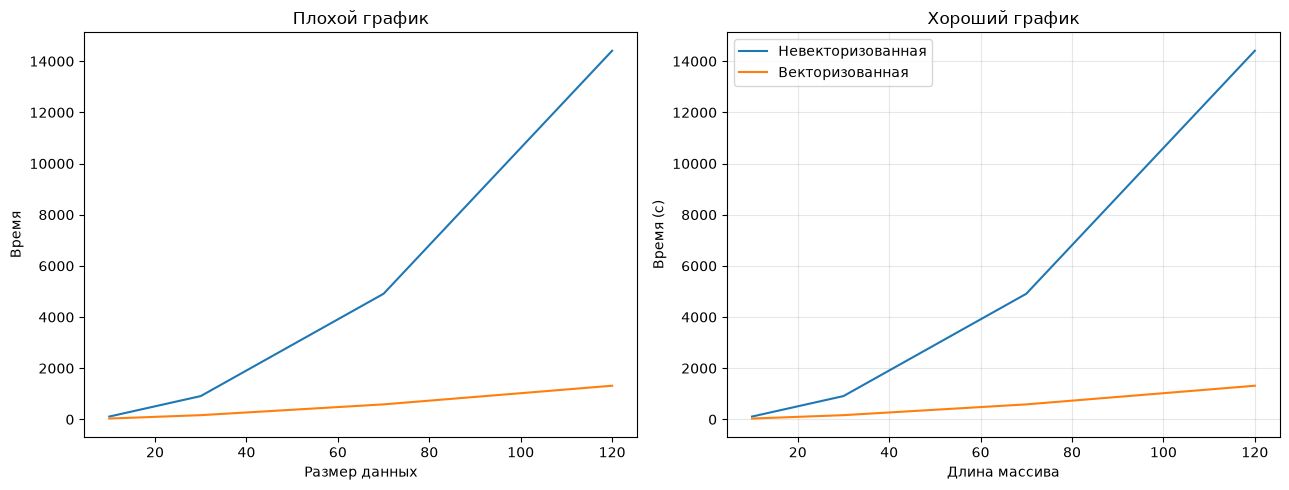

In [2]:
from importlib import reload

import matplotlib.pyplot as plt
import numpy as np

import functions
import functions_vectorized

%matplotlib inline


def reload_solution_modules():
    """Reload the two local solution modules after their files change."""
    reload(functions)
    reload(functions_vectorized)


data_size = np.array([10, 30, 70, 120])
time_non_vectorized = data_size**2 + 10
time_vectorized = data_size**1.5

figure, (axis_bad, axis_good) = plt.subplots(1, 2, figsize=(13, 5))

axis_bad.plot(data_size, time_non_vectorized)
axis_bad.plot(data_size, time_vectorized)
axis_bad.set_title("Плохой график")
axis_bad.set_xlabel("Размер данных")
axis_bad.set_ylabel("Время")

axis_good.plot(data_size, time_non_vectorized, label="Невекторизованная")
axis_good.plot(data_size, time_vectorized, label="Векторизованная")
axis_good.set_title("Хороший график")
axis_good.set_xlabel("Длина массива")
axis_good.set_ylabel("Время (с)")
axis_good.grid(True, alpha=0.3)
axis_good.legend()

figure.tight_layout()
plt.show()


* __Задача 1__: Подсчитать произведение ненулевых элементов на диагонали прямоугольной матрицы.  
 Например, для X = np.array([[1, 0, 1], [2, 0, 2], [3, 0, 3], [4, 4, 4]]) ответ – 3.

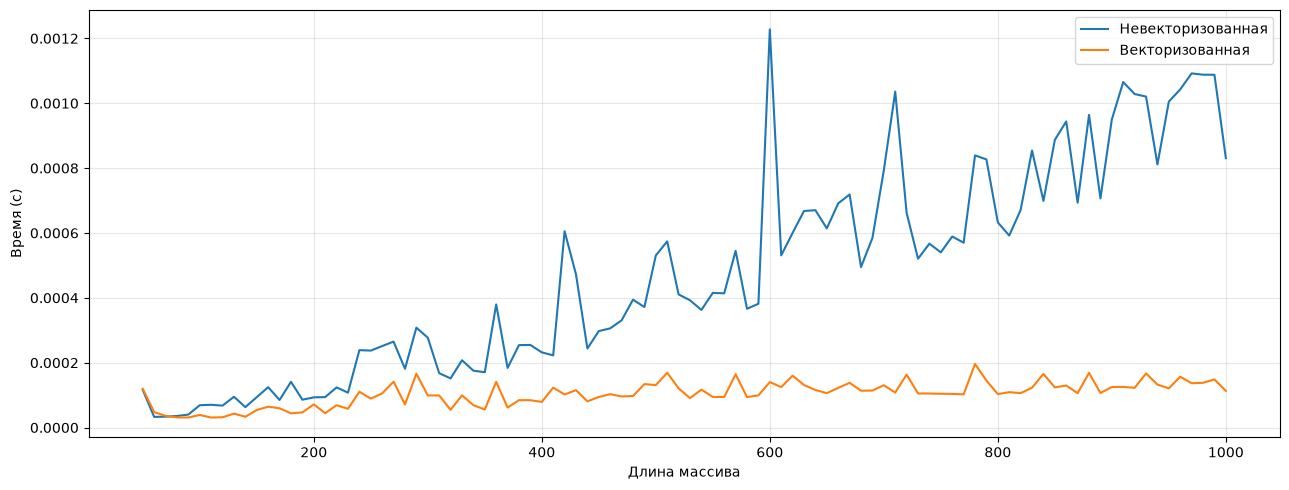

In [98]:
import time
import numpy as np
import matplotlib.pyplot as plt

def functions(x):
    ans = 1
    for i in range(len(x)):
        if i == len(x[i]):
            break
        if x[i][i] != 0:
            ans *= x[i][i]
    return ans
    
def functions_vectorized(x):
    d = np.diag(x)
    ans = d[d != 0].prod()
    return ans

t1 = []
t2 = []
si = []
for i in range(50, 1001, 10): si.append(i)
for i in si:
    x2 = (np.random.default_rng()).integers(-10, 10, size=(i, i))
    x1 = x2.tolist()
    s1 = time.perf_counter()
    functions(x1)
    t1.append(time.perf_counter() - s1)
    s2 = time.perf_counter()
    functions_vectorized(x2)
    t2.append(time.perf_counter() - s2)


figure, (axis_good) = plt.subplots(1, 1, figsize=(13, 5))


axis_good.plot(si, t1 , label="Невекторизованная")
axis_good.plot(si, t2, label="Векторизованная")
axis_good.set_xlabel("Длина массива")
axis_good.set_ylabel("Время (с)")
axis_good.grid(True, alpha=0.3)
axis_good.legend()

figure.tight_layout()
plt.show()



In [ ]:
 
 
* __Задача 2__: Даны два вектора x и y. Проверить, задают ли они одно и то же мультимножество.  
  Например, для x = np.array([1, 2, 2, 4]), y = np.array([4, 2, 1, 2]) ответ – True.
  
  


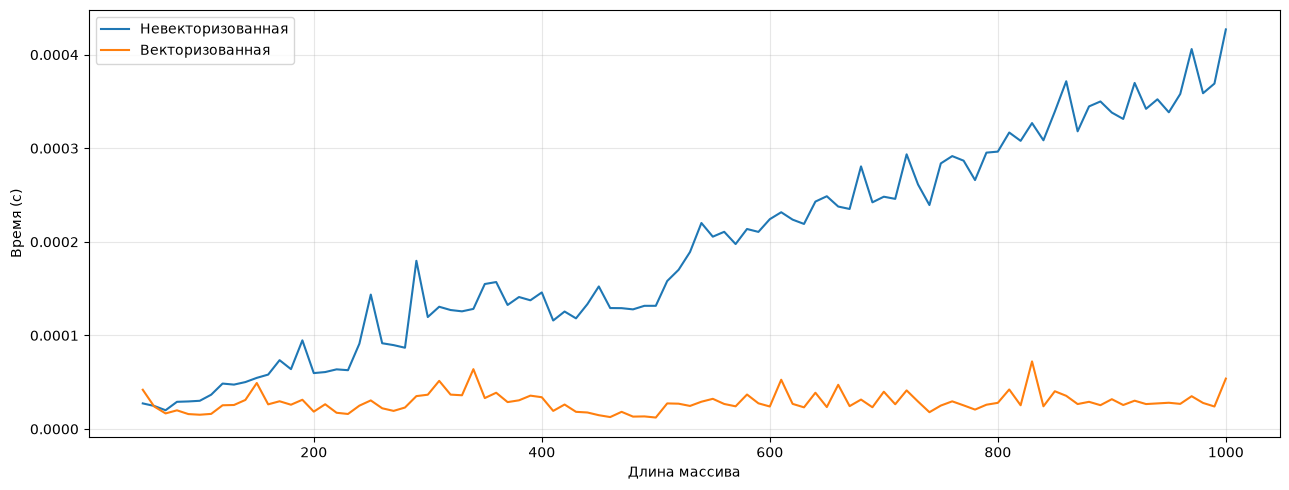

In [100]:
import time
import numpy as np
import matplotlib.pyplot as plt

def functions(x, y):
    x.sort()
    y.sort()
    fl = 1
    if len(x) != len(y): fl = 0
    for i in range(min(len(x), len(y))):
        if x[i] != y[i]:
            fl = 0
    if fl == 1:
        return True
    return False

def functions_vectorized(x, y):
    return np.array_equal(x, y)

t1 = []
t2 = []
si = []
for i in range(50, 1001, 10): si.append(i)
for i in si:
    x2 = (np.random.default_rng()).integers(-10, 10, size=i)
    x1 = x2.tolist()
    y2 = (np.random.default_rng()).integers(-10, 10, size=i)
    y1 = x2.tolist()
    s1 = time.perf_counter()
    functions(x1, y1)
    t1.append(time.perf_counter() - s1)
    s2 = time.perf_counter()
    functions_vectorized(x2, y2)
    t2.append(time.perf_counter() - s2)

figure, (axis_good) = plt.subplots(1, 1, figsize=(13, 5))
axis_good.plot(si, t1 , label="Невекторизованная")
axis_good.plot(si, t2, label="Векторизованная")
axis_good.set_xlabel("Длина массива")
axis_good.set_ylabel("Время (с)")
axis_good.grid(True, alpha=0.3)
axis_good.legend()

figure.tight_layout()
plt.show()

            


* __Задача 3__: Найти максимальный элемент в векторе x среди элементов, перед которыми стоит нулевой.  
 Например, для x = np.array([6, 2, 0, 3, 0, 0, 5, 7, 0]) ответ – 5.

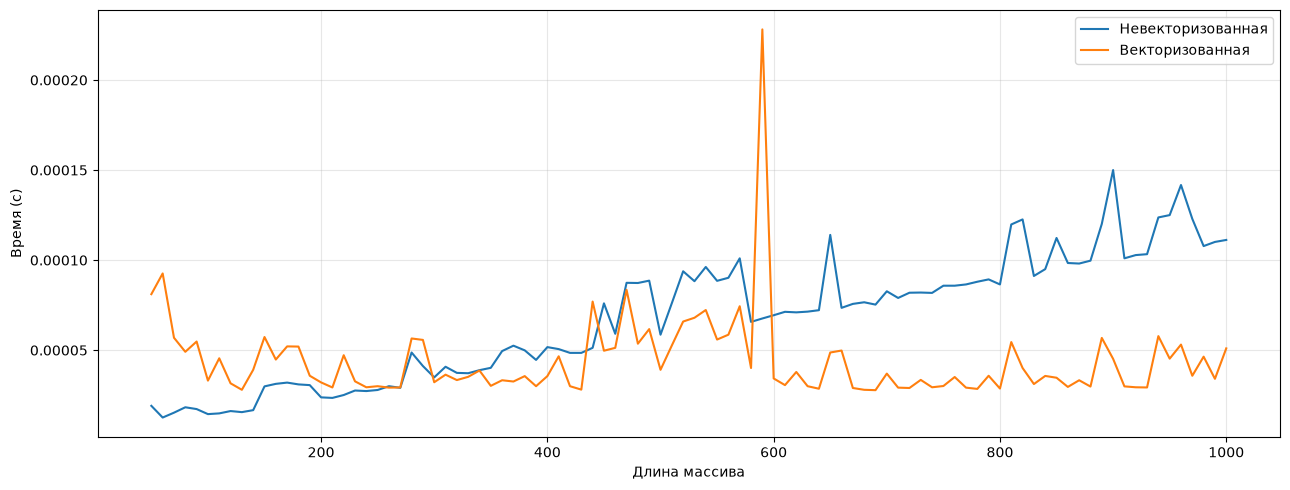

In [119]:

import time
import numpy as np
import matplotlib.pyplot as plt

def functions(x):
    ans = 0
    for i in range(0, len(x) - 1):
        if x[i] == 0:
            ans = max(ans, x[i + 1])
    return ans
    
def functions_vectorized(x):
    d = x[1:][x[:-1] == 0]
    d = np.append(d, 0)
    return d.max()

t1 = []
t2 = []
si = []
for i in range(50, 1001, 10): si.append(i)
for i in si:
    x2 = (np.random.default_rng()).integers(-10, 10, size=i)
    x1 = x2.tolist()
    s1 = time.perf_counter()
    functions(x1)
    t1.append(time.perf_counter() - s1)
    s2 = time.perf_counter()
    functions_vectorized(x2)
    t2.append(time.perf_counter() - s2)


figure, (axis_good) = plt.subplots(1, 1, figsize=(13, 5))


axis_good.plot(si, t1 , label="Невекторизованная")
axis_good.plot(si, t2, label="Векторизованная")
axis_good.set_xlabel("Длина массива")
axis_good.set_ylabel("Время (с)")
axis_good.grid(True, alpha=0.3)
axis_good.legend()

figure.tight_layout()
plt.show()

    
    

 
 
* __Задача 4__: Дан трёхмерный массив, содержащий изображение, размера (height, width, numChannels), а также вектор длины numChannels. Сложить каналы изображения с указанными весами, и вернуть результат в виде матрицы размера (height, width). В ноутбуке приведите пример работы функции – преобразуйте цветное изображение в оттенки серого, использовав коэффициенты np.array([0.299, 0.587, 0.114]). Считать реальное изображение можно с помощью `PIL.Image.open` из пакета Pillow: `img = np.asarray(Image.open(path).convert("RGB"))`. Устаревшая функция `scipy.misc.imread` удалена из современных версий SciPy.


* __Задача 5__: Реализовать кодирование длин серий (Run-length encoding). Для некоторого вектора x необходимо вернуть кортеж из двух векторов одинаковой длины. Первый содержит числа, а второй - сколько раз их нужно повторить.  
 Например, для x = np.array([2, 2, 2, 3, 3, 3, 5]) ответ – (np.array([2, 3, 5]), np.array([3, 3, 1])).

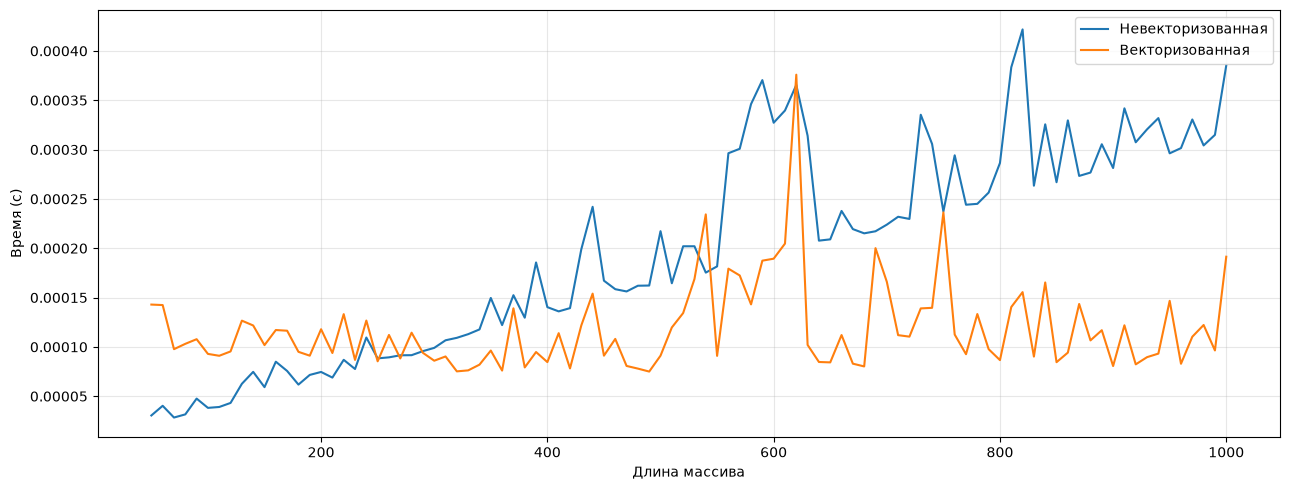

In [118]:
from random import randint
import numpy as np

def functions(x):
    a1 = [x[0]]
    b1 = [1]
    for i in range(1, len(x)):
        if x[i] == x[i - 1]:
            b1[-1] += 1
        else:
            a1.append(x[i])
            b1.append(1)
    
    
def functions_vectorized(x):   
    m = x[1:] != x[:-1]
    ind = np.where(m)[0] + 1
    s = np.insert(ind, 0, 0)
    ans = x[s]
    e = np.append(ind, len(x))
    count = e - s


t1 = []
t2 = []
si = []
for i in range(50, 1001, 10): si.append(i)
for i in si:
    x2 = (np.random.default_rng()).integers(-10, 10, size=i)
    x1 = x2.tolist()
    s1 = time.perf_counter()
    functions(x1)
    t1.append(time.perf_counter() - s1)
    s2 = time.perf_counter()
    functions_vectorized(x2)
    t2.append(time.perf_counter() - s2)


figure, (axis_good) = plt.subplots(1, 1, figsize=(13, 5))


axis_good.plot(si, t1 , label="Невекторизованная")
axis_good.plot(si, t2, label="Векторизованная")
axis_good.set_xlabel("Длина массива")
axis_good.set_ylabel("Время (с)")
axis_good.grid(True, alpha=0.3)
axis_good.legend()

figure.tight_layout()
plt.show()
    


 
 
* __Задача 6__: Даны две выборки объектов - X и Y. Вычислить матрицу евклидовых расстояний между объектами. Дополнительно сравните с функцией scipy.spatial.distance.cdist по скорости работы (сравнения приведите ниже в ноутбуке).

In [108]:
reload_solution_modules()

# code here


ImportError: module functions not in sys.modules

### Туториал по Markdown

__(1 балл)__

Напишите краткий (а в данной домашке ещё и почти бесмысленный) отчёт с использованием 4-5 различных вариантов разметки/выделения текста.

In [8]:
# code here